# Figure 6C — Evoked dopamine release triggered on optogenetic stimulation

Replication of Figure 6C from Chen et al. 2026.  
**Average GRAB-DA3m corrected signal** triggered on optogenetic stimulation light onset at **0.5 mW**.

- Blue trace: LRRK2-G2019S mice (Anxa-GS, n = 8 mice, 64 stimulations)
- Grey trace: WT mice (Anxa-WT, n = 7 mice, 56 stimulations)
- Red shade: light stimulation window
- Dashed lines: isosbestic control (corrected 405 nm channel)
- Shaded regions: mean ± SEM across stimulations

Data source: NWB files in `nwb-output/sub-*-anxa-{gs,wt}/`.  
Series used: `processing/ophys/FiberPhotometryResponseSeriesCorrectedSignal` (470 nm) and  
`processing/ophys/FiberPhotometryResponseSeriesCorrectedIsosbesticControl` (405 nm).  
Epochs: `intervals/OptogeneticEpochsTable`, filtered to `power_in_mW == 0.5`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import pynwb

In [10]:
NWB_DIR = Path('/Users/weian/lrrk2_data/nwb-output')

POWER_MW = 0.5   # filter to this power level
PRE_S    = 2.0   # seconds before stim onset
POST_S   = 5.0   # seconds after stim onset

# 0.5 mW stims use 10 ms period × 32 pulses → ~330 ms train
STIM_DURATION_S = 0.33

COLOR_GS  = '#2166AC'
COLOR_WT  = '#636363'
COLOR_RED = '#D73027'

In [11]:
def load_peri_event(nwb_path, power_mw=0.5, pre=2.0, post=5.0):
    """
    Extract peri-event windows of corrected470 and corrected405 around each stimulation
    onset at `power_mw` from one NWB file.

    Returns
    -------
    windows_470 : (n_stims, n_samples) array
    windows_405 : (n_stims, n_samples) array
    time_axis   : (n_samples,) array of seconds relative to stim onset
    """
    with pynwb.NWBHDF5IO(str(nwb_path), 'r', load_namespaces=True) as io:
        nwb = io.read()

        ophys = nwb.processing['ophys']
        c470_series = ophys['FiberPhotometryResponseSeriesCorrectedSignal']
        c405_series = ophys['FiberPhotometryResponseSeriesCorrectedIsosbesticControl']

        ts   = np.array(c470_series.timestamps)
        d470 = np.array(c470_series.data,  dtype=float)
        d405 = np.array(c405_series.data,  dtype=float)

        fps    = 1.0 / np.median(np.diff(ts))
        n_pre  = int(pre  * fps)
        n_post = int(post * fps)

        epochs = nwb.intervals['OptogeneticEpochsTable'].to_dataframe()
        stims  = epochs[np.isclose(epochs['power_in_mW'], power_mw, atol=0.01)]

        windows_470, windows_405, time_axis = [], [], None

        for _, row in stims.iterrows():
            onset_idx = np.searchsorted(ts, row['start_time'])
            i0 = onset_idx - n_pre
            i1 = onset_idx + n_post
            if i0 < 0 or i1 > len(ts):
                continue

            windows_470.append(d470[i0:i1].copy())
            windows_405.append(d405[i0:i1].copy())
            if time_axis is None:
                time_axis = ts[i0:i1] - row['start_time']

    return np.array(windows_470), np.array(windows_405), time_axis

In [12]:
gs_files = sorted(NWB_DIR.glob('sub-*-anxa-gs/*.nwb'))
wt_files = sorted(NWB_DIR.glob('sub-*-anxa-wt/*.nwb'))

print(f'GS files: {len(gs_files)}, WT files: {len(wt_files)}')

all_gs_470, all_gs_405 = [], []
all_wt_470, all_wt_405 = [], []
time_axis = None

for f in gs_files:
    w470, w405, t = load_peri_event(f, POWER_MW, PRE_S, POST_S)
    if w470.size:
        all_gs_470.append(w470)
        all_gs_405.append(w405)
        if time_axis is None:
            time_axis = t
    print(f'  {f.parent.name}: {len(w470)} stims @ {POWER_MW} mW')

for f in wt_files:
    w470, w405, t = load_peri_event(f, POWER_MW, PRE_S, POST_S)
    if w470.size:
        all_wt_470.append(w470)
        all_wt_405.append(w405)
        if time_axis is None:
            time_axis = t
    print(f'  {f.parent.name}: {len(w470)} stims @ {POWER_MW} mW')

gs_470 = np.vstack(all_gs_470)
gs_405 = np.vstack(all_gs_405)
wt_470 = np.vstack(all_wt_470)
wt_405 = np.vstack(all_wt_405)

print(f'\nTotal GS: {len(gs_470)} stims, WT: {len(wt_470)} stims')

GS files: 8, WT files: 7
  sub-3742-anxa-gs: 8 stims @ 0.5 mW
  sub-3743-anxa-gs: 8 stims @ 0.5 mW
  sub-4004-anxa-gs: 8 stims @ 0.5 mW
  sub-4005-anxa-gs: 8 stims @ 0.5 mW
  sub-4007-anxa-gs: 8 stims @ 0.5 mW
  sub-4651-anxa-gs: 8 stims @ 0.5 mW
  sub-4652-anxa-gs: 8 stims @ 0.5 mW
  sub-4885-anxa-gs: 8 stims @ 0.5 mW
  sub-3947-anxa-wt: 8 stims @ 0.5 mW
  sub-3948-anxa-wt: 8 stims @ 0.5 mW
  sub-4253-anxa-wt: 8 stims @ 0.5 mW
  sub-4398-anxa-wt: 8 stims @ 0.5 mW
  sub-4401-anxa-wt: 8 stims @ 0.5 mW
  sub-4558-anxa-wt: 8 stims @ 0.5 mW
  sub-4561-anxa-wt: 8 stims @ 0.5 mW

Total GS: 64 stims, WT: 56 stims


In [13]:
def mean_sem(arr):
    m = arr.mean(axis=0)
    s = arr.std(axis=0, ddof=1) / np.sqrt(len(arr))
    return m, s

gs_470_m, gs_470_s = mean_sem(gs_470)
gs_405_m, gs_405_s = mean_sem(gs_405)
wt_470_m, wt_470_s = mean_sem(wt_470)
wt_405_m, wt_405_s = mean_sem(wt_405)

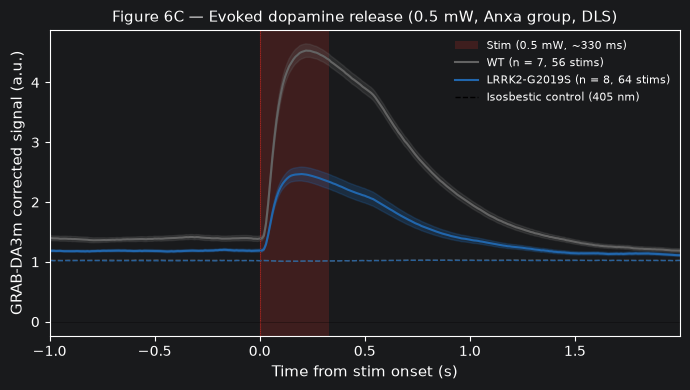

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

# Red shading: stimulation window
ax.axvspan(0, STIM_DURATION_S, color=COLOR_RED, alpha=0.20, lw=0, label='Stim (0.5 mW, ~330 ms)')
ax.axvline(0, color=COLOR_RED, lw=0.8, ls='-', alpha=0.6)

# WT traces — grey
ax.fill_between(time_axis, wt_470_m - wt_470_s, wt_470_m + wt_470_s,
                color=COLOR_WT, alpha=0.25)
ax.plot(time_axis, wt_470_m, color=COLOR_WT, lw=1.5,
        label=f'WT (n = 7, {len(wt_470)} stims)')
ax.plot(time_axis, wt_405_m, color=COLOR_WT, lw=1.0, ls='--', alpha=0.8)

# GS traces — blue
ax.fill_between(time_axis, gs_470_m - gs_470_s, gs_470_m + gs_470_s,
                color=COLOR_GS, alpha=0.25)
ax.plot(time_axis, gs_470_m, color=COLOR_GS, lw=1.5,
        label=f'LRRK2-G2019S (n = 8, {len(gs_470)} stims)')
ax.plot(time_axis, gs_405_m, color=COLOR_GS, lw=1.0, ls='--', alpha=0.8)

# Reference lines
ax.axhline(0, color='k', lw=0.5, alpha=0.4)
ax.axvline(0, color='k', lw=0.5, ls=':', alpha=0.5)

# Legend entry for isosbestic dashes
iso_patch = plt.Line2D([0], [0], color='k', lw=1.0, ls='--', label='Isosbestic control (405 nm)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [iso_patch], labels + ['Isosbestic control (405 nm)'],
          loc='upper right', frameon=False, fontsize=8)

ax.set_xlabel('Time from stim onset (s)', fontsize=11)
ax.set_ylabel('GRAB-DA3m corrected signal (a.u.)', fontsize=11)
ax.set_title('Figure 6C — Evoked dopamine release (0.5 mW, Anxa group, DLS)', fontsize=11)
ax.set_xlim(-1, 2.0)
ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5])

plt.tight_layout()
plt.show()

---
## Figure 6C — All power levels (0.1, 0.5, 1.0, 4.0 mW)

Four vertically stacked panels, one per power level.  
Blue: LRRK2-G2019S (n = 8, 64 stims per power); Grey: WT (n = 7, 56 stims per power).  
Shaded regions: mean ± SEM across stimulations.  
Series used: `processing/ophys/FiberPhotometryResponseSeriesCorrectedSignal` (470 nm) and  
`processing/ophys/FiberPhotometryResponseSeriesCorrectedIsosbesticControl` (405 nm).

In [15]:
def load_all_powers(nwb_path, powers, pre=2.0, post=5.0):
    """
    Open one NWB file and extract peri-event windows for multiple power levels
    in a single pass.  Returns a dict keyed by power with (windows_470, windows_405)
    and a shared time_axis.
    """
    results   = {p: ([], []) for p in powers}
    time_axis = None

    with pynwb.NWBHDF5IO(str(nwb_path), 'r', load_namespaces=True) as io:
        nwb   = io.read()
        ophys = nwb.processing['ophys']
        ts    = np.array(ophys['FiberPhotometryResponseSeriesCorrectedSignal'].timestamps)
        d470  = np.array(ophys['FiberPhotometryResponseSeriesCorrectedSignal'].data,               dtype=float)
        d405  = np.array(ophys['FiberPhotometryResponseSeriesCorrectedIsosbesticControl'].data, dtype=float)

        fps    = 1.0 / np.median(np.diff(ts))
        n_pre  = int(pre  * fps)
        n_post = int(post * fps)

        epochs = nwb.intervals['OptogeneticEpochsTable'].to_dataframe()

        for power in powers:
            stims = epochs[np.isclose(epochs['power_in_mW'], power, atol=0.01)]
            w470s, w405s = [], []
            for _, row in stims.iterrows():
                idx = np.searchsorted(ts, row['start_time'])
                i0, i1 = idx - n_pre, idx + n_post
                if i0 < 0 or i1 > len(ts):
                    continue
                w470s.append(d470[i0:i1].copy())
                w405s.append(d405[i0:i1].copy())
                if time_axis is None:
                    time_axis = ts[i0:i1] - row['start_time']
            results[power] = (w470s, w405s)

    return results, time_axis

# --- collect data for all four powers (one file-open per animal) ---
POWERS = [0.1, 0.5, 1.0, 4.0]

pool = {p: {'gs_470': [], 'gs_405': [], 'wt_470': [], 'wt_405': []} for p in POWERS}
t_multi = None

for f in gs_files:
    res, t = load_all_powers(f, POWERS, PRE_S, POST_S)
    for p in POWERS:
        w470, w405 = res[p]
        pool[p]['gs_470'].extend(w470)
        pool[p]['gs_405'].extend(w405)
    if t_multi is None and t is not None:
        t_multi = t

for f in wt_files:
    res, t = load_all_powers(f, POWERS, PRE_S, POST_S)
    for p in POWERS:
        w470, w405 = res[p]
        pool[p]['wt_470'].extend(w470)
        pool[p]['wt_405'].extend(w405)
    if t_multi is None and t is not None:
        t_multi = t

# convert lists → arrays
for p in POWERS:
    for k in pool[p]:
        pool[p][k] = np.array(pool[p][k])

for p in POWERS:
    print(f'{p:4.1f} mW  GS: {len(pool[p]["gs_470"])} stims   WT: {len(pool[p]["wt_470"])} stims')

 0.1 mW  GS: 64 stims   WT: 56 stims
 0.5 mW  GS: 64 stims   WT: 56 stims
 1.0 mW  GS: 64 stims   WT: 56 stims
 4.0 mW  GS: 64 stims   WT: 55 stims


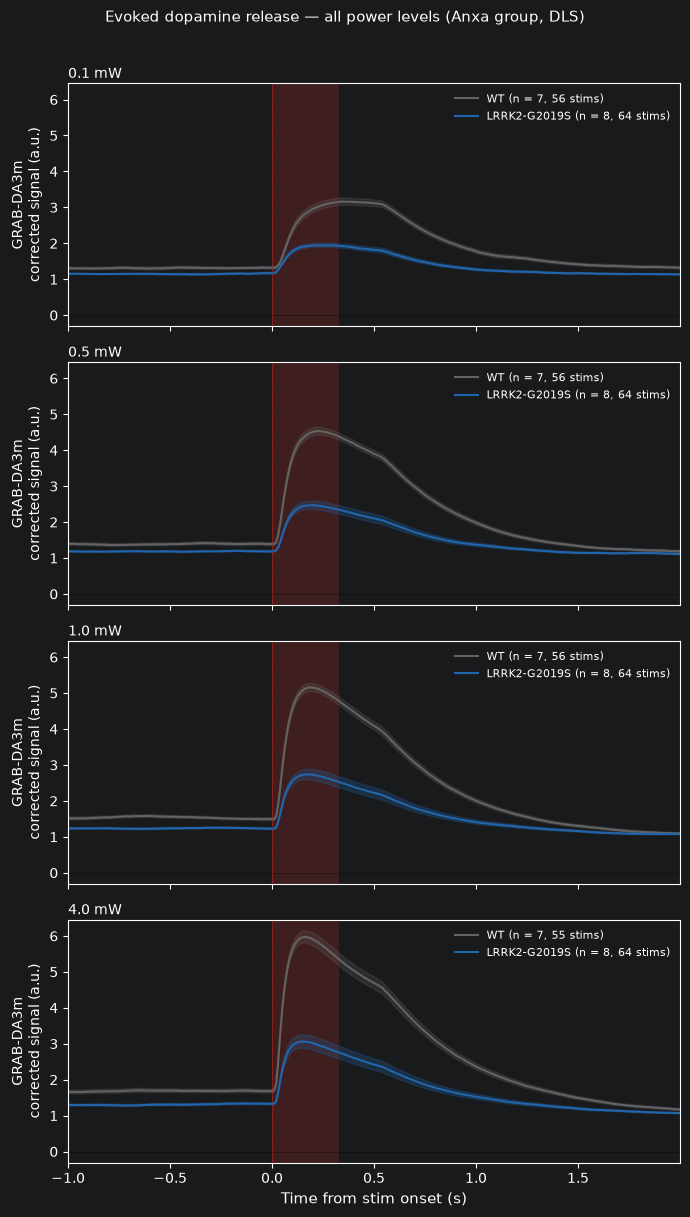

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(7, 12), sharex=True, sharey=True)

for ax, power in zip(axes, POWERS):
    gs_470_m, gs_470_s = mean_sem(pool[power]['gs_470'])
    wt_470_m, wt_470_s = mean_sem(pool[power]['wt_470'])

    n_gs = len(pool[power]['gs_470'])
    n_wt = len(pool[power]['wt_470'])

    # Red stim shading (~330 ms for all four powers, which are in the 10 ms period group)
    ax.axvspan(0, STIM_DURATION_S, color=COLOR_RED, alpha=0.20, lw=0)
    ax.axvline(0, color=COLOR_RED, lw=0.8, ls='-', alpha=0.6)

    # WT — grey
    ax.fill_between(t_multi, wt_470_m - wt_470_s, wt_470_m + wt_470_s,
                    color=COLOR_WT, alpha=0.25)
    ax.plot(t_multi, wt_470_m, color=COLOR_WT, lw=1.5,
            label=f'WT (n = 7, {n_wt} stims)')

    # GS — blue
    ax.fill_between(t_multi, gs_470_m - gs_470_s, gs_470_m + gs_470_s,
                    color=COLOR_GS, alpha=0.25)
    ax.plot(t_multi, gs_470_m, color=COLOR_GS, lw=1.5,
            label=f'LRRK2-G2019S (n = 8, {n_gs} stims)')

    ax.axhline(0, color='k', lw=0.5, alpha=0.4)
    ax.axvline(0, color='k', lw=0.5, ls=':', alpha=0.5)

    ax.set_ylabel('GRAB-DA3m\ncorrected signal (a.u.)', fontsize=10)
    ax.set_title(f'{power} mW', fontsize=10, loc='left', pad=4)
    ax.legend(loc='upper right', frameon=False, fontsize=8)

axes[0].set_xlim(-1, 2.0)
axes[0].set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5])

axes[-1].set_xlabel('Time from stim onset (s)', fontsize=11)

fig.suptitle('Evoked dopamine release — all power levels (Anxa group, DLS)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()